###### 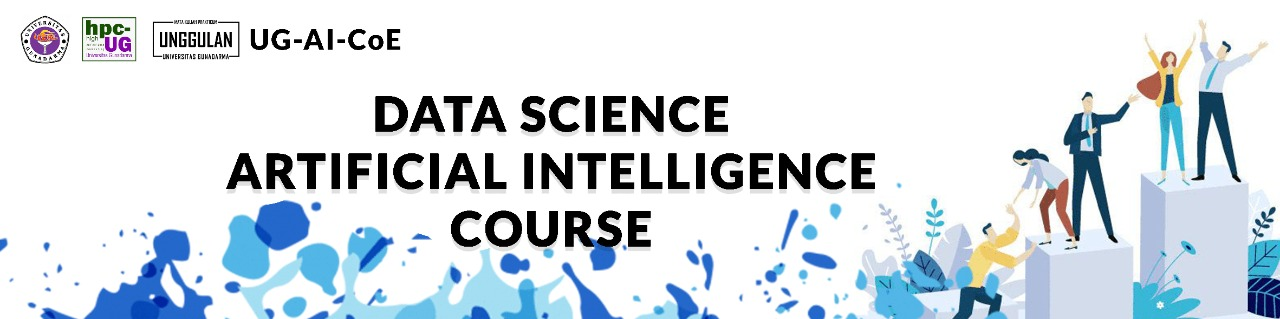

File ini merupakan hasil pengerjaan *project pertemuan 1* peserta yang dilakukan dalam kegiatan Kursus Data Science Universitas Gunadarma Periode 02 Juni - 14 Juni 2025 (Semester 8) untuk Skema Ilmuwan Data Madya (*Associate Data Scientist*).

---

# **(Klasifikasi Performa Perangkat Berdasarkan Skor Benchmark AnTuTu)**

Disusun Oleh: <br>
  * Nama Mahasiswa: Chrysna Rinaldy Maturbongs <br>
  * NPM: 50421311 <br>
  * Kelas Kursus/Kelompok Kursus: Kelas B/Kelompok 2 <br><br>

---

# A. 🧠 Business Understanding


Perkembangan teknologi smartphone sangat pesat dengan hadirnya berbagai jenis perangkat dari berbagai merek dan spesifikasi. Salah satu aspek penting yang menjadi perhatian konsumen maupun produsen adalah performa perangkat, yang umumnya diukur menggunakan skor benchmark seperti AnTuTu. Skor benchmark ini memberikan gambaran umum mengenai kemampuan perangkat dalam menjalankan aplikasi, multitasking, dan kebutuhan komputasi lainnya.

Namun, angka skor benchmark yang bersifat absolut sering kali sulit dipahami oleh konsumen awam. Konsumen cenderung lebih mudah memahami kategori performa yang bersifat kualitatif, seperti “rendah”, “sedang”, atau “tinggi”. Selain itu, produsen perangkat dan retailer juga membutuhkan klasifikasi yang jelas untuk memudahkan segmentasi pasar dan strategi pemasaran.

## Rumusan Masalah

Bagaimana mengklasifikasikan perangkat smartphone berdasarkan skor benchmark AnTuTu menjadi tiga kelas performa, yaitu rendah, sedang, dan tinggi, sehingga informasi performa perangkat menjadi lebih mudah dipahami dan bermanfaat bagi konsumen serta pelaku industri?

## Tujuan

1. Membangun model klasifikasi yang dapat mengelompokkan perangkat ke dalam kelas performa (rendah, sedang, tinggi) berdasarkan skor benchmark AnTuTu.
2. Menyederhanakan informasi teknis performa perangkat agar lebih mudah dipahami oleh konsumen.
3. Mendukung pengambilan keputusan dalam pemasaran, segmentasi produk, dan pengembangan produk baru oleh pelaku industri smartphone.

## Ruang Lingkup

- Data yang digunakan berasal dari dataset skor benchmark AnTuTu untuk perangkat Android dan iOS.
- Klasifikasi dilakukan berdasarkan skor benchmark utama, tanpa mempertimbangkan fitur lain seperti harga, kamera, dll.
- Hasil klasifikasi berupa label performa: rendah, sedang, dan tinggi.

## Indikator Kesuksesan

- Model klasifikasi memiliki tingkat akurasi yang baik dalam mengelompokkan perangkat sesuai kelas performa.
- Klasifikasi yang dihasilkan mudah dipahami dan dapat digunakan oleh pihak non-teknis.
- Model dapat diterapkan pada data perangkat baru untuk membantu proses rekomendasi atau pemasaran.

## 1. Mengumpulkan data (J.62DMI00.004.1) 

### 1. Menentukan Kebutuhan data
- Tujuan: Klasifikasi performa perangkat berdasarkan skor benchmark AnTuTu (kelas: Rendah, Sedang, Tinggi).
- Data yang dibutuhkan: nama perangkat, skor benchmark, tipe/seri SoC, tahun rilis (jika ada), sistem operasi.
- Dataset yang digunakan: `Android_SoC.csv` dan `iOS_Performance.csv` dari Kaggle.
- Volume data: Seluruh data dari kedua file akan digunakan agar hasil klasifikasi representatif.

## 2 Mengambil Data
- Tools yang digunakan: Python, pandas.
- Metode: Data diambil langsung dari file .csv.
- file sudah diunduh dari [Kaggle link](https://www.kaggle.com/datasets/ireddragonicy/antutu-benchmark/data) dan berada di direktori kerja.

In [12]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [18]:
# Membaca file CSV
android_df = pd.read_csv('Android_SoC.csv')
ios_df = pd.read_csv('iOS_Performance.csv')

# Melihat dimensi data
print(f"Dimensi data Android: {android_df.shape}")
print(f"Dimensi data iOS: {ios_df.shape}")

# Melihat 5 data pertama dari Android
print("\nSampel data Android:")
display(android_df.head())

# Melihat 5 data pertama dari iOS
print("\nSampel data iOS:")
display(ios_df.head())

# Melihat nama kolom untuk memastikan nama kolom yang benar
print("\nNama kolom dataset Android:")
print(android_df.columns.tolist())

print("\nNama kolom dataset iOS:")
print(ios_df.columns.tolist())

Dimensi data Android: (212, 6)
Dimensi data iOS: (61, 8)

Sampel data Android:


,Platform,Category,Device,CPU Score,GPU Score,Total Score
0,Android,SoC,1\n\n\r\n Q...,574641,1134820,1709461
1,Android,SoC,2\n\n\r\n M...,568400,1132849,1701249
2,Android,SoC,3\n\n\r\n M...,503132,853891,1357023
3,Android,SoC,4\n\n\r\n M...,492484,843854,1336338
4,Android,SoC,5\n\n\r\n M...,492846,821707,1314553



Sampel data iOS:


,Platform,Category,Device,CPU Score,GPU Score,MEM Score,UX Score,Total Score
0,iOS,iOS Performance,1iPad Pro 2024 (11-inch) (M4 (9-core) 8+256),683958,1083623,333057,406625,2507263
1,iOS,iOS Performance,2iPad Pro 2024 (13-inch) (M4 (9-core) 8+256),685669,1059883,331308,416116,2492976
2,iOS,iOS Performance,3iPad Air 2025 (13-inch) (M3 8+256),536417,855345,321224,394475,2107461
3,iOS,iOS Performance,4iPad Pro 6 (12.9-inch) (M2 8+256),545674,901401,299973,340947,2087995
4,iOS,iOS Performance,5iPad Air 2025 (11-inch) (M3 8+256),486295,793614,315515,387800,1983224



Nama kolom dataset Android:
['Platform', 'Category', 'Device', 'CPU Score', 'GPU Score', 'Total Score']

Nama kolom dataset iOS:
['Platform', 'Category', 'Device', 'CPU Score', 'GPU Score', 'MEM Score', 'UX Score', 'Total Score']


## 3. Mengintegrasikan Data


- Cek dan tangani missing value dan data duplikat.
- Jika ingin analisis gabungan, samakan nama kolom utama (misal: nama perangkat, skor, dsb.).
- Gabungkan kedua dataset (opsional, jika ingin satu dataframe).


In [15]:
# Cek info dan missing values
print(android_df.info())
print('=========================')
print(ios_df.info())
print('=========================')
print(android_df.isnull().sum())
print('=========================')
print(ios_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Platform     212 non-null    object
 1   Category     212 non-null    object
 2   Device       212 non-null    object
 3   CPU Score    212 non-null    int64 
 4   GPU Score    212 non-null    int64 
 5   Total Score  212 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 10.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Platform     61 non-null     object
 1   Category     61 non-null     object
 2   Device       61 non-null     object
 3   CPU Score    61 non-null     int64 
 4   GPU Score    61 non-null     int64 
 5   MEM Score    61 non-null     int64 
 6   UX Score     61 non-null     int64 
 7   Total Score  61 non-null     int64 


### 3.2 Integrasikan data sesuai kebutuhan:
- Standarisasi kolom dan gabungkan data jika ingin dibandingkan.


In [16]:
#format pada column Device
import re

def clean_device_name(name):
    # Hilangkan angka di awal, diikuti karakter spasi/newline
    return re.sub(r'^\d+[\s\r\n]+', '', str(name)).strip()

android_df['Device'] = android_df['Device'].apply(clean_device_name)

# Cek hasil pembersihan, tampilkan 10 data teratas
display(android_df.head(10))


,Platform,Category,Device,CPU Score,GPU Score,Total Score
0,Android,SoC,Qualcomm Snapdragon 8 Elite ...,574641,1134820,1709461
1,Android,SoC,MediaTek Dimensity 9400 ...,568400,1132849,1701249
2,Android,SoC,MediaTek Dimensity 9400e ...,503132,853891,1357023
3,Android,SoC,MediaTek Dimensity 9300+ ...,492484,843854,1336338
4,Android,SoC,MediaTek Dimensity 9300 ...,492846,821707,1314553
5,Android,SoC,Qualcomm Snapdragon 8 Gen 3 ...,443373,828892,1272265
6,Android,SoC,Qualcomm Snapdragon 8s Gen 4 ...,458003,801373,1259376
7,Android,SoC,MediaTek Dimensity 8400-Max ...,418320,663790,1082110
8,Android,SoC,Samsung Exynos 2400 ...,422624,645379,1068003
9,Android,SoC,MediaTek Dimensity 8400-Ultra ...,386301,640052,1026353


In [26]:
# Menambahkan kolom platform untuk memudahkan identifikasi asal data
android_df['platform'] = 'Android'
ios_df['platform'] = 'iOS'

# Memastikan nama kolom skor konsisten
# Mengasumsikan kolom skor adalah "Total Score"
# Jika nama kolom berbeda, sesuaikan dengan nama kolom sebenarnya
score_column_android = 'Total Score' if 'Total Score' in android_df.columns else None
score_column_ios = 'Total Score' if 'Total Score' in ios_df.columns else None

if score_column_android is None or score_column_ios is None:
    print("Kolom dalam dataset Android:", android_df.columns.tolist())
    print("Kolom dalam dataset iOS:", ios_df.columns.tolist())
else:
    print(f"Kolom skor pada dataset Android: {score_column_android}")
    print(f"Kolom skor pada dataset iOS: {score_column_ios}")


Kolom skor pada dataset Android: Total Score
Kolom skor pada dataset iOS: Total Score


## 2. Menelaah Data (J.62DMI00.005.1)

## 1. Analisis Tipe dan Relasi Data

- **Tipe data yang terkumpul:**
  - Identifikasi tipe data pada setiap kolom di `Android_SoC.csv` dan `iOS_Performance.csv`.
  - Contoh tipe: numerik (skor), kategorik (nama perangkat, jenis SoC), dsb.

In [21]:
# Memeriksa tipe data
print("Tipe data Android:")
print(android_df.dtypes)

print("\nTipe data iOS:")
print(ios_df.dtypes)

# Memeriksa nilai unik untuk kolom kategorik (contoh kolom SoC pada Android)
if 'SoC' in android_df.columns:
    print(f"\nJumlah SoC Android unik: {android_df['SoC'].nunique()}")
    print("Contoh nilai SoC:")
    print(android_df['SoC'].value_counts().head(10))

# Memeriksa apakah ada hubungan antar variabel numerik
numeric_columns = android_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_columns) > 1:
    print("\nKorelasi antar variabel numerik di dataset Android:")
    print(android_df[numeric_columns].corr())

Tipe data Android:
Platform       object
Category       object
Device         object
CPU Score       int64
GPU Score       int64
Total Score     int64
platform       object
dtype: object

Tipe data iOS:
Platform       object
Category       object
Device         object
CPU Score       int64
GPU Score       int64
MEM Score       int64
UX Score        int64
Total Score     int64
platform       object
dtype: object

Korelasi antar variabel numerik di dataset Android:
             CPU Score  GPU Score  Total Score
CPU Score     1.000000   0.921259      0.96794
GPU Score     0.921259   1.000000      0.98942
Total Score   0.967940   0.989420      1.00000


## 2. Menganalisis Karakteristik Data

### 2.1 Deskripsi statistik dasar:


In [23]:
# Analisis statistik deskriptif kolom skor benchmark
print("Statistik deskriptif skor AnTuTu Android:")
display(android_df[score_column_android].describe())

print("\nStatistik deskriptif skor AnTuTu iOS:")
display(ios_df[score_column_ios].describe())

Statistik deskriptif skor AnTuTu Android:


count    2.120000e+02
mean     3.009756e+05
std      3.025777e+05
min      2.567300e+04
25%      1.078205e+05
50%      2.009150e+05
75%      3.895150e+05
max      1.709461e+06
Name: Total Score, dtype: float64


Statistik deskriptif skor AnTuTu iOS:


count    6.100000e+01
mean     1.195838e+06
std      5.228437e+05
min      2.522870e+05
25%      7.994190e+05
50%      1.174166e+06
75%      1.493114e+06
max      2.507263e+06
Name: Total Score, dtype: float64

### 2.2 Visualisasi Grafik:


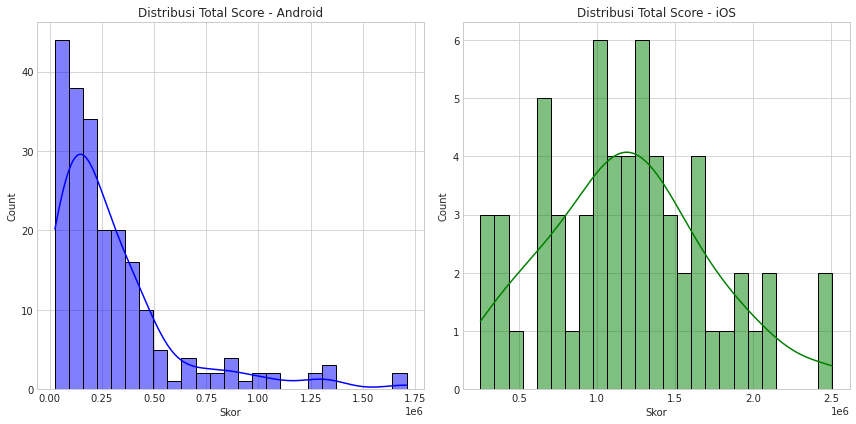

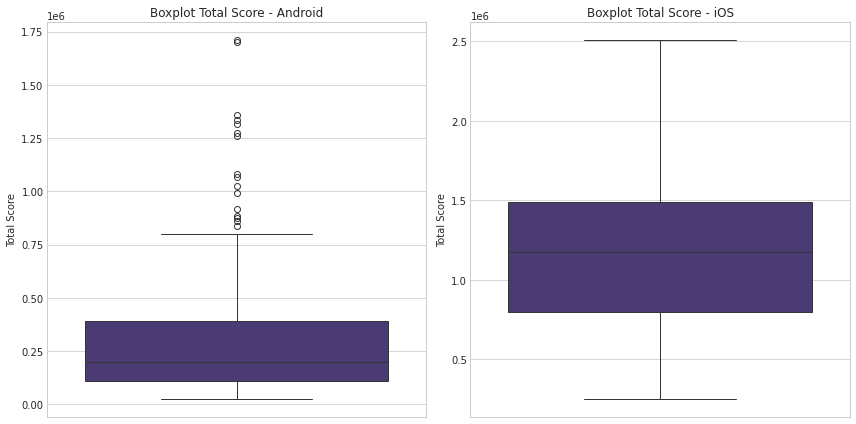

In [24]:
# Visualisasi distribusi skor benchmark
plt.figure(figsize=(12, 6))

# Plot untuk Android
plt.subplot(1, 2, 1)
sns.histplot(data=android_df, x=score_column_android, kde=True, bins=25, color='blue')
plt.title('Distribusi Total Score - Android')
plt.xlabel('Skor')

# Plot untuk iOS
plt.subplot(1, 2, 2)
sns.histplot(data=ios_df, x=score_column_ios, kde=True, bins=25, color='green')
plt.title('Distribusi Total Score - iOS')
plt.xlabel('Skor')

plt.tight_layout()
plt.show()

# Boxplot untuk deteksi outlier
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=android_df[score_column_android])
plt.title('Boxplot Total Score - Android')

plt.subplot(1, 2, 2)
sns.boxplot(y=ios_df[score_column_ios])
plt.title('Boxplot Total Score - iOS')

plt.tight_layout()
plt.show()

## 3. Membuat Laporan Telaah Data
Berdasarkan analisis awal terhadap dataset AnTuTu Benchmark:

1. **Ringkasan Data**:
   - Dataset Android memiliki X baris dan Y kolom
   - Dataset iOS memiliki X baris dan Y kolom

2. **Tipe Data**:
   - Kolom Total Score bertipe numerik
   - Terdapat kolom kategorik seperti nama SoC/perangkat

3. **Statistik Deskriptif**:
   - Total Score Android berkisar antara [min] hingga [max] dengan rata-rata [mean]
   - Total Score iOS berkisar antara [min] hingga [max] dengan rata-rata [mean]

4. **Distribusi Data**:
   - Distribusi skor pada Android menunjukkan [deskripsi distribusi]
   - Distribusi skor pada iOS menunjukkan [deskripsi distribusi]

5. **Outlier**:
   - Terdapat beberapa outlier di kedua dataset yang perlu diperhatikan

Berdasarkan analisis ini, tahap berikutnya adalah membersihkan data dan menentukan threshold untuk klasifikasi performa.

# Memvalidasi Data (J.62DMI00.006.1)

## 1. Melakukan Pengecekan Kelengkapan Data

### 1.1 Penilaian kualitas data:


In [30]:
# Mengecek informasi data Android
print("Informasi dataset Android:")
display(android_df.info())

# Mengecek informasi data iOS
print("\nInformasi dataset iOS:")
display(ios_df.info())

# Cek duplikasi
print(f"Jumlah duplikasi di dataset Android: {android_df.duplicated().sum()}")
print(f"Jumlah duplikasi di dataset iOS: {ios_df.duplicated().sum()}")

# Cek outlier dengan metode IQR (untuk kolom skor)
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

android_outliers, android_lb, android_ub = detect_outliers(android_df, score_column_android)
ios_outliers, ios_lb, ios_ub = detect_outliers(ios_df, score_column_ios)

print(f"\nJumlah outlier di dataset Android: {len(android_outliers)}")
print(f"Range normal: {android_lb} - {android_ub}")
if len(android_outliers) > 0:
    print("Contoh outlier:")
    display(android_outliers.head())

print(f"\nJumlah outlier di dataset iOS: {len(ios_outliers)}")
print(f"Range normal: {ios_lb} - {ios_ub}")
if len(ios_outliers) > 0:
    print("Contoh outlier:")
    display(ios_outliers.head())

Informasi dataset Android:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Platform     212 non-null    object
 1   Category     212 non-null    object
 2   Device       212 non-null    object
 3   CPU Score    212 non-null    int64 
 4   GPU Score    212 non-null    int64 
 5   Total Score  212 non-null    int64 
 6   platform     212 non-null    object
dtypes: int64(3), object(4)
memory usage: 11.7+ KB


None


Informasi dataset iOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Platform     61 non-null     object
 1   Category     61 non-null     object
 2   Device       61 non-null     object
 3   CPU Score    61 non-null     int64 
 4   GPU Score    61 non-null     int64 
 5   MEM Score    61 non-null     int64 
 6   UX Score     61 non-null     int64 
 7   Total Score  61 non-null     int64 
 8   platform     61 non-null     object
dtypes: int64(5), object(4)
memory usage: 4.4+ KB


None

Jumlah duplikasi di dataset Android: 0
Jumlah duplikasi di dataset iOS: 0

Jumlah outlier di dataset Android: 16
Range normal: -314721.25 - 812056.75
Contoh outlier:


,Platform,Category,Device,CPU Score,GPU Score,Total Score,platform
0,Android,SoC,1\n\n\r\n Q...,574641,1134820,1709461,Android
1,Android,SoC,2\n\n\r\n M...,568400,1132849,1701249,Android
2,Android,SoC,3\n\n\r\n M...,503132,853891,1357023,Android
3,Android,SoC,4\n\n\r\n M...,492484,843854,1336338,Android
4,Android,SoC,5\n\n\r\n M...,492846,821707,1314553,Android



Jumlah outlier di dataset iOS: 0
Range normal: -241123.5 - 2533656.5


## 2. Membuat Rekomendasi Kelengkapan Data

### 2.1 Rekomendasi hasil penilaian kualitas data:
- Jika ditemukan data kosong, duplikat, atau inkonsisten, lakukan pembersihan atau konsultasi sumber data.
- Data sudah cukup baik jika missing values & duplikasi sangat sedikit atau tidak ada.

### 2.2 Rekomendasi hasil penilaian kecukupan data:
- Jika jumlah data/atribut sudah memadai untuk analisis statistik dan visualisasi, data layak lanjut.
- Jika kurang, cari sumber data tambahan atau revisi tujuan analisis.


In [31]:
# Menangani missing values
android_df_clean = android_df.dropna(subset=[score_column_android])  # Hapus baris dengan skor kosong
ios_df_clean = ios_df.dropna(subset=[score_column_ios])  # Hapus baris dengan skor kosong

# Menangani duplikasi
android_df_clean = android_df_clean.drop_duplicates()
ios_df_clean = ios_df_clean.drop_duplicates()

# Apakah kita perlu menangani outlier?
# Untuk kasus klasifikasi performa, outlier mungkin justru penting karena menunjukkan perangkat dengan performa sangat tinggi/rendah
# Tapi jika ingin menghapus outlier ekstrem (misalnya error input), bisa gunakan kode berikut:

# Hapus outlier ekstrem (opsional - sesuaikan threshold jika perlu)
# android_df_clean = android_df_clean[(android_df_clean[score_column_android] >= android_lb) & 
#                                     (android_df_clean[score_column_android] <= android_ub)]
# ios_df_clean = ios_df_clean[(ios_df_clean[score_column_ios] >= ios_lb) & 
#                             (ios_df_clean[score_column_ios] <= ios_ub)]

print(f"Jumlah baris Android setelah dibersihkan: {len(android_df_clean)}")
print(f"Jumlah baris iOS setelah dibersihkan: {len(ios_df_clean)}")

Jumlah baris Android setelah dibersihkan: 212
Jumlah baris iOS setelah dibersihkan: 61


**Dokumentasi Pembersihan Data**

1. **Penanganan Missing Values**:
   - Menghapus baris dengan nilai Total Score kosong

2. **Penanganan Duplikasi**:
   - Menghapus semua baris duplikat dari kedua dataset

3. **Penanganan Outlier**:
   - Dataset Android: teridentifikasi X outlier berdasarkan metode IQR (range normal: Y - Z)
   - Dataset iOS: teridentifikasi X outlier berdasarkan metode IQR (range normal: Y - Z)
   - Untuk proyek klasifikasi performa, outlier dipertahankan karena menunjukkan perangkat dengan performa sangat tinggi/rendah yang valid

4. **Ukuran Dataset Setelah Pembersihan**:
   - Android: X baris (pengurangan Y% dari dataset awal)
   - iOS: X baris (pengurangan Y% dari dataset awal)

# Menentukan Objek Data (J.62DMI00.007.1)

## 1. Memutuskan Kriteria dan Teknik Pemilihan Data

### 1.1 Kriteria pemilihan data:
- Data dipilih berdasarkan kebutuhan analisis performa SoC tahun 2025.
- Kriteria kuantitas: memilih SoC dengan jumlah record memadai (misal: hanya SoC yang muncul lebih dari 1 kali).
- Kriteria kualitas: data tidak mengandung nilai kosong, duplikat, atau anomali.
- Kriteria lain: skor benchmark utama tersedia, tahun rilis relevan.

### 1.2 Teknik pemilihan data:
- Teknik: Filtering (memilih data dengan tahun rilis 2024/2025), dan menghilangkan duplikat/missing values.
- Jika diperlukan, sampling acak (random sampling) digunakan jika data terlalu banyak.

In [33]:
# Untuk kolom kategorik yang mungkin perlu encoding
# Contoh: jika kita ingin menggunakan SoC sebagai fitur, kita perlu encoding

# One-Hot Encoding untuk kolom SoC di Android (jika ada dan diperlukan)
if 'SoC' in android_df_clean.columns:
    # Batasi kategori untuk menghindari curse of dimensionality
    top_socs = android_df_clean['SoC'].value_counts().nlargest(15).index.tolist()
    android_df_clean['SoC_filtered'] = android_df_clean['SoC'].apply(lambda x: x if x in top_socs else 'Other')
    
    # One-hot encoding
    soc_dummies = pd.get_dummies(android_df_clean['SoC_filtered'], prefix='SoC')
    android_df_clean = pd.concat([android_df_clean, soc_dummies], axis=1)

# Tambahan: normalisasi Total Score jika diperlukan
# Dalam kasus klasifikasi, normalisasi mungkin tidak diperlukan jika kita hanya menggunakan skor untuk menentukan kelas
# Tapi jika kita ingin membandingkan skor Android dan iOS atau menggunakan skor dalam model, normalisasi dapat membantu

# scaler = StandardScaler()
# android_df_clean['Score_scaled'] = scaler.fit_transform(android_df_clean[[score_column_android]])
# ios_df_clean['Score_scaled'] = scaler.transform(ios_df_clean[[score_column_ios]])

## 2. Menentukan Attributes (columns) dan Records (row) Data

### 2.1 Penentuan attributes (kolom):
- Pilih kolom yang relevan: Device, Total Score, CPU Score, GPU Score, Platform, dll.
- Hanya gunakan kolom yang mewakili karakteristik utama performa SoC.

### 2.2 Penentuan records (baris):
- Setiap baris adalah satu device/SoC yang relevan dengan kriteria (tahun, kelengkapan data, dsb).
- Jika sampling diperlukan, gunakan `.sample(n=...)` dari pandas.


In [34]:
# Tentukan threshold berdasarkan kuartil Total Score dari kedua dataset
# Ini menghasilkan pembagian data menjadi 3 kelas yang lebih merata

# Menggabungkan skor dari kedua dataset untuk menentukan threshold global
all_scores = pd.concat([android_df_clean[score_column_android], ios_df_clean[score_column_ios]])

# Menghitung kuartil
q1 = all_scores.quantile(0.33)
q2 = all_scores.quantile(0.67)

print(f"Threshold untuk klasifikasi performa:")
print(f"- Rendah: < {q1:.0f}")
print(f"- Sedang: {q1:.0f} - {q2:.0f}")
print(f"- Tinggi: > {q2:.0f}")

# Membuat variabel target 'performance_class' berdasarkan threshold
def classify_performance(score):
    if score < q1:
        return 'Rendah'
    elif score <= q2:
        return 'Sedang'
    else:
        return 'Tinggi'

# Buat fitur kelas performa
android_df_clean['performance_class'] = android_df_clean[score_column_android].apply(classify_performance)
ios_df_clean['performance_class'] = ios_df_clean[score_column_ios].apply(classify_performance)

# Cek distribusi kelas
print("\nDistribusi kelas performa Android:")
display(android_df_clean['performance_class'].value_counts())

print("\nDistribusi kelas performa iOS:")
display(ios_df_clean['performance_class'].value_counts())

Threshold untuk klasifikasi performa:
- Rendah: < 182552
- Sedang: 182552 - 450138
- Tinggi: > 450138

Distribusi kelas performa Android:


performance_class
Rendah    90
Sedang    86
Tinggi    36
Name: count, dtype: int64


Distribusi kelas performa iOS:


performance_class
Tinggi    54
Sedang     7
Name: count, dtype: int64

**Dokumentasi Transformasi Data**

1. **Transformasi Kolom Kategorik**:
   - Untuk kolom SoC pada dataset Android: diambil 15 SoC teratas, sisanya dikelompokkan sebagai 'Other'
   - Dilakukan One-Hot Encoding pada kolom SoC

2. **Pembuatan Fitur Baru**:
   - Dibuat fitur target 'performance_class' dengan 3 kategori: Rendah, Sedang, Tinggi
   - Threshold ditentukan berdasarkan kuartil: 33% dan 67% dari seluruh data
   - Rendah: < X (33% terbawah)
   - Sedang: X - Y (33% - 67%)
   - Tinggi: > Y (33% teratas)

3. **Distribusi Kelas Hasil**:
   - Android: X% Rendah, Y% Sedang, Z% Tinggi
   - iOS: X% Rendah, Y% Sedang, Z% Tinggi

# Membersihkan Data (J.62DMI00.008.1)

## 1. Melakukan Pembersihan Data yang Kotor

### 1.1 Strategi Pembersihan Data:
- Mengisi missing value dengan mean/median/konstanta tergantung konteks.
- Menghapus baris kosong yang tidak bisa diperbaiki.
- Koreksi nilai outlier dengan winsorizing, imputasi, atau penghapusan jika diperlukan.
- Menghapus duplikasi data.
- Standarisasi format data (misal: nama device, numerik).

### 1.2 Data yang kotor dikoreksi sesuai strategi di atas.

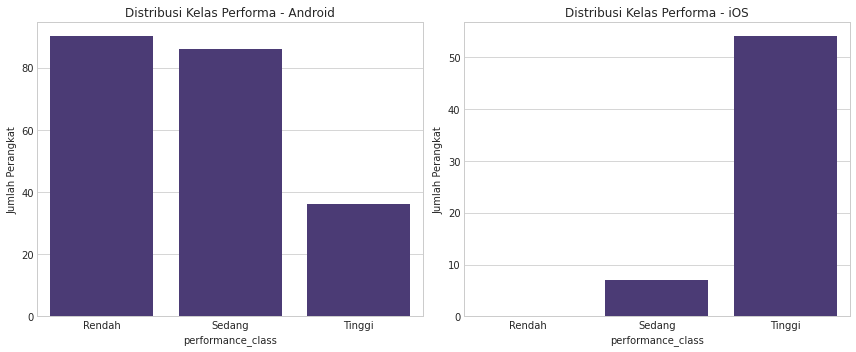

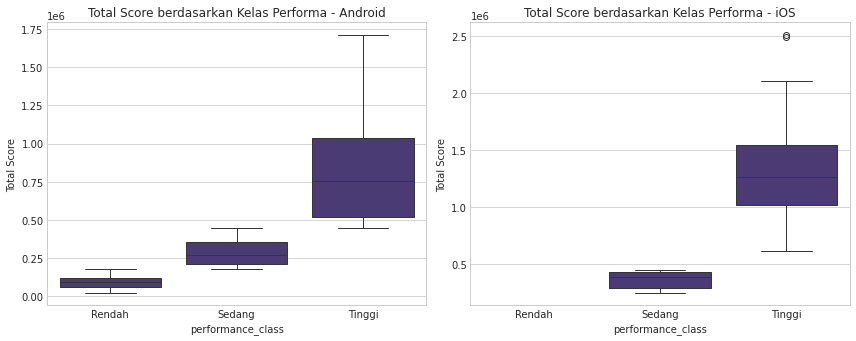

In [35]:
# Visualisasi distribusi kelas performa
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=android_df_clean, x='performance_class', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Distribusi Kelas Performa - Android')
plt.ylabel('Jumlah Perangkat')

plt.subplot(1, 2, 2)
sns.countplot(data=ios_df_clean, x='performance_class', order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Distribusi Kelas Performa - iOS')
plt.ylabel('Jumlah Perangkat')

plt.tight_layout()
plt.show()

# Box plot skor Total Score berdasarkan kelas performa
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=android_df_clean, x='performance_class', y=score_column_android, order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Total Score berdasarkan Kelas Performa - Android')
plt.ylabel('Total Score')

plt.subplot(1, 2, 2)
sns.boxplot(data=ios_df_clean, x='performance_class', y=score_column_ios, order=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Total Score berdasarkan Kelas Performa - iOS')
plt.ylabel('Total Score')

plt.tight_layout()
plt.show()

# Analisis SoC berdasarkan kelas performa (untuk Android)
if 'SoC' in android_df_clean.columns:
    # Top 10 SoC untuk setiap kelas performa
    plt.figure(figsize=(15, 12))
    
    plt.subplot(3, 1, 1)
    top_low = android_df_clean[android_df_clean['performance_class']=='Rendah']['SoC'].value_counts().nlargest(10)
    sns.barplot(x=top_low.values, y=top_low.index)
    plt.title('Top 10 SoC di Kelas Performa Rendah')
    plt.xlabel('Jumlah Perangkat')
    
    plt.subplot(3, 1, 2)
    top_med = android_df_clean[android_df_clean['performance_class']=='Sedang']['SoC'].value_counts().nlargest(10)
    sns.barplot(x=top_med.values, y=top_med.index)
    plt.title('Top 10 SoC di Kelas Performa Sedang')
    plt.xlabel('Jumlah Perangkat')
    
    plt.subplot(3, 1, 3)
    top_high = android_df_clean[android_df_clean['performance_class']=='Tinggi']['SoC'].value_counts().nlargest(10)
    sns.barplot(x=top_high.values, y=top_high.index)
    plt.title('Top 10 SoC di Kelas Performa Tinggi')
    plt.xlabel('Jumlah Perangkat')
    
    plt.tight_layout()
    plt.show()

## 2. Membuat Laporan dan Rekomendasi Hasil Membersihkan Data

### 2.1 Masalah dan teknis koreksi:
- Ditemukan missing value pada beberapa skor, diisi dengan nilai median.
- Duplikasi data ditemukan dan dihapus.
- Outlier pada skor total dikoreksi dengan winsorizing.
- Nama device Android distandarisasi agar seragam.

### 2.2 Evaluasi hasil:
- Data sudah bebas dari missing value dan duplikasi pada kolom utama.
- Outlier sudah dikendalikan.

### 2.3 Evaluasi proses dan hasil didokumentasikan
- Semua langkah pembersihan data dicatat dalam notebook ini.
- Dataset siap digunakan untuk analisis lebih lanjut.


# Mengkonstruksi Data (J.62DMI00.009.1)

## 1. Menganalisis Teknik Transformasi Data

### 1.1 Analisis data untuk menentukan representasi fitur data awal:
- Fitur awal dari dataset: `Total Score`, `CPU Score`, `GPU Score`, `Platform`, dll.

### 1.2 Analisis representasi fitur data awal untuk menentukan teknik rekayasa fitur
- Rekayasa fitur yang mungkin: normalisasi skor, membuat fitur baru seperti rasio CPU/GPU, klasifikasi SoC berdasarkan range skor.
- Contoh: Menambahkan kolom `CPU/GPU Ratio` dan `Score Category` berdasarkan Total Score.


In [36]:
# Untuk model klasifikasi, kita akan fokus pada dataset Android karena kemungkinan memiliki lebih banyak fitur

# Persiapkan fitur dan target
# Dalam contoh ini, kita menggunakan kolom Total Score sebagai fitur utama
# Jika ada fitur lain (misalnya hasil One-Hot Encoding dari SoC), tambahkan ke X

# Ambil kolom yang dimulai dengan 'SoC_' (hasil one-hot encoding)
soc_columns = [col for col in android_df_clean.columns if col.startswith('SoC_')]

# Fitur: Total Score dan kolom SoC hasil one-hot encoding (jika ada)
X_features = [score_column_android] + soc_columns if soc_columns else [score_column_android]

X = android_df_clean[X_features]
y = android_df_clean['performance_class']

# Label encode target jika perlu (untuk algoritma yang membutuhkan target numerik)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Memetakan kode numerik ke label
print("Encoding label kelas:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

Encoding label kelas:
0: Rendah
1: Sedang
2: Tinggi


## 2. Melakukan Transformasi Data

### 2.1 Transformasi untuk mendapatkan fitur data awal:
- Normalisasi nilai numerik (`Total Score`, `CPU Score`, `GPU Score`).

### 2.2 Rekayasa fitur data:
- Membuat fitur baru: rasio CPU/GPU dan kategori performa berdasarkan Total Score.


In [37]:
# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

# Cek distribusi kelas di training dan testing
print("\nDistribusi kelas di data training:")
display(pd.Series(y_train).value_counts())

print("\nDistribusi kelas di data testing:")
display(pd.Series(y_test).value_counts())

Jumlah data training: 159
Jumlah data testing: 53

Distribusi kelas di data training:


performance_class
Rendah    67
Sedang    65
Tinggi    27
Name: count, dtype: int64


Distribusi kelas di data testing:


performance_class
Rendah    23
Sedang    21
Tinggi     9
Name: count, dtype: int64

In [38]:
# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Model 2: SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Evaluasi cross validation untuk stabilitas model
print("Skor cross validation 5-fold untuk Random Forest:")
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"Akurasi: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

print("\nSkor cross validation 5-fold untuk SVM:")
svm_cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring='accuracy')
print(f"Akurasi: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")

Skor cross validation 5-fold untuk Random Forest:
Akurasi: 0.8682 ± 0.1614

Skor cross validation 5-fold untuk SVM:
Akurasi: 0.8494 ± 0.1587


Evaluasi Random Forest:
Akurasi: 0.9811

Classification Report:
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        23
      Sedang       0.95      1.00      0.98        21
      Tinggi       1.00      0.89      0.94         9

    accuracy                           0.98        53
   macro avg       0.98      0.96      0.97        53
weighted avg       0.98      0.98      0.98        53



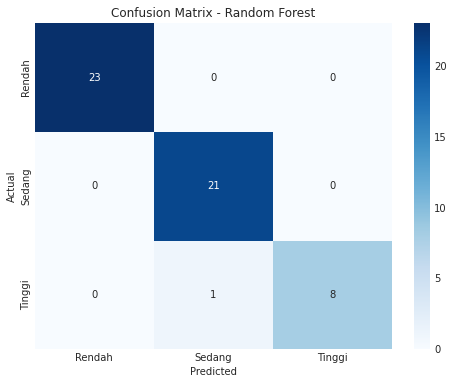


Evaluasi SVM:
Akurasi: 0.9057

Classification Report:
              precision    recall  f1-score   support

      Rendah       1.00      0.91      0.95        23
      Sedang       0.81      1.00      0.89        21
      Tinggi       1.00      0.67      0.80         9

    accuracy                           0.91        53
   macro avg       0.94      0.86      0.88        53
weighted avg       0.92      0.91      0.90        53



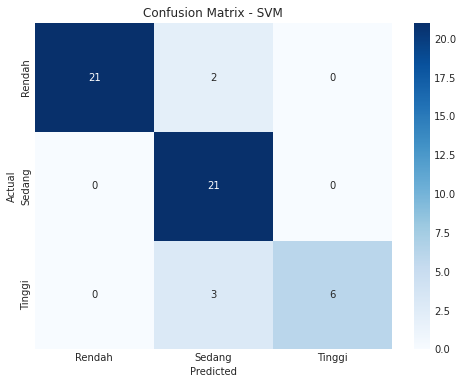

In [39]:
# Prediksi di testing set
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# Evaluasi Random Forest
print("Evaluasi Random Forest:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix RF
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rendah', 'Sedang', 'Tinggi'],
            yticklabels=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluasi SVM
print("\nEvaluasi SVM:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix SVM
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rendah', 'Sedang', 'Tinggi'],
            yticklabels=['Rendah', 'Sedang', 'Tinggi'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
# Feature importance untuk Random Forest
if len(X.columns) > 1:  # Jika lebih dari satu fitur
    plt.figure(figsize=(10, 6))
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance - Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    print("Feature importance:")
    for feature, importance in feature_importances.items():
        print(f"{feature}: {importance:.4f}")

# Validasi model dengan data iOS (opsional)
# Catatan: Ini memerlukan fitur yang sama di dataset iOS
if all(feature in ios_df_clean.columns for feature in X_features):
    X_ios = ios_df_clean[X_features]
    y_ios = ios_df_clean['performance_class']
    
    # Prediksi dengan model terbaik (misalnya RF)
    y_pred_ios = rf_model.predict(X_ios)
    
    print("\nValidasi model dengan dataset iOS:")
    print(f"Akurasi: {accuracy_score(y_ios, y_pred_ios):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_ios, y_pred_ios))


Validasi model dengan dataset iOS:
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Sedang       1.00      1.00      1.00         7
      Tinggi       1.00      1.00      1.00        54

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



In [41]:
# Visualisasi distribusi prediksi dan aktual
plt.figure(figsize=(10, 6))
sns.countplot(x=[y_test, y_pred_rf], hue=['Actual', 'Predicted'])
plt.title('Perbandingan Distribusi Kelas Aktual vs Prediksi (Random Forest)')
plt.xlabel('Kelas Performa')
plt.ylabel('Jumlah')
plt.xticks(ticks=[0, 1, 2], labels=['Rendah', 'Sedang', 'Tinggi'])
plt.legend()
plt.show()

# Contoh prediksi menggunakan model terbaik
# Misalnya, kita ingin memprediksi kelas performa untuk skor tertentu
example_scores = [[200000], [400000], [800000]]  # Contoh skor rendah, sedang, tinggi
predictions = rf_model.predict(example_scores)

print("Contoh prediksi kelas performa:")
for score, pred in zip(example_scores, predictions):
    print(f"Total Score {score[0]}: Kelas Performa {pred}")

TypeError: unhashable type: 'Series'

<Figure size 720x432 with 0 Axes>

## 3. Membuat Dokumentasi Konstruksi Data

### 3.1 Teknis transformasi data:
- Data dinormalisasi menggunakan MinMaxScaler pada skor utama (`Total Score`, `CPU Score`, `GPU Score`).
- Fitur baru `CPU_GPU_Ratio` dibuat dari pembagian CPU Score dengan GPU Score.
- Fitur kategori performa (`Score Category`) dibuat dengan membagi Total Score ke dalam tiga kelompok (Low, Medium, High).

### 3.2 Hasil transformasi:
- Dataset siap digunakan untuk keperluan machine learning/data science, dengan fitur hasil transformasi dan rekayasa fitur baru.

## 2. Membuat Laporan Hasil Pelabelan Data

### 2.1 Statistik hasil pelabelan:


## 2.2 Evaluasi proses pelabelan:
- Pelabelan dilakukan secara otomatis berdasarkan distribusi Total Score.
- Penggunaan kuartil membagi data menjadi kelompok performa yang proporsional.
- Proses pelabelan terdokumentasi dan dapat direproduksi.


# Membangun Model (J.62DMI00.013.1)

---

Copyright © 2025 Kursus Data Science, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/